# Create Plots Showing the Grid Response in the Three Pairs of Case Studies


In [1]:
# Start by importing the packages we need:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Suppress Warnings


In [2]:
# Suppress future warnings:
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None


## Set the Directory Structure

In [3]:
# Set the data input and output directories:
events_data_input_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/data/thermal_events_data/'
image_output_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/figures/'


## Calculate and Plot the Stress Metrics for the Case Studies


In [7]:
def plot_case_studies(event_list: list, event_label: list, hw_cs: str, events_data_input_dir: str, image_output_dir: str, image_resolution: int, save_images=False):

    # Extract the heat wave or cold snap library data for a given NERC region:
    if hw_cs == 'HW':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'hw_library_expanded.csv'))
    elif hw_cs == 'CS':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'cs_library_expanded.csv'))

    # Loop over the list of events and extract the data for that event into a combined dataframe:
    for i in range(len(event_list)):
            
        # Subset to just the data for event in the list:
        subset_df = hw_cs_df[(hw_cs_df['UID'] == event_list[i])].copy()
        
        # Aggregate the output into a new dataframe:
        if i == 0:
           event_df = subset_df
        else:
           event_df = pd.concat([event_df, subset_df])

    # Add in the row number for plotting:
    event_df['Row'] = range(len(event_df))
    event_df['Row'] = event_df['Row']+ 1

    # Reset the index:
    event_df.reset_index(inplace=True, drop=True)
    
    # Add in the event label:
    for i in range(len(event_df)):
        event_df.at[i, 'Label'] = event_label[i]
        
    # Drop columns to make it easier to see the data:
    event_df.drop(['UID', 'NERC', 'Center', 'Center_DOY', 'Duration', 'Regions_Impacted', 'Renew_at_Peak'], axis=1, inplace=True)

    # Make the event plot:
    plt.figure(figsize=(22, 22))
    plt.rcParams['font.size'] = 18
    plt.rcParams['axes.axisbelow'] = True

    ax1 = plt.subplot(221)
    event_df.plot.bar(x='Label',y=['Max_LMP'], stacked=False, color=['darkorange'], ax=ax1)
    ax1.legend_ = None
    plt.xticks(rotation=0)
    plt.xlabel('') 
    plt.ylabel('Maximum Locational Marginal Price During Event [$/MWh]')
    plt.title('a)', loc='left', fontsize=18)
    plt.title('Locational Marginal Prices')

    ax2 = plt.subplot(222)
    event_df.plot.bar(x='Label',y=['Max_Load_Shed'], stacked=False, color=['darkorange'], ax=ax2)
    ax2.legend_ = None
    plt.xticks(rotation=0)
    plt.xlabel('') 
    plt.ylabel('Maximum Unserved Energy During Event [MW]')
    plt.title('b)', loc='left', fontsize=18)
    plt.title('Unserved Energy')

    ax3 = plt.subplot(223)
    event_df.plot.bar(x='Label',y=['Import_at_Peak'], stacked=False, color=['darkorange'], ax=ax3)
    ax3.legend_ = None
    plt.xticks(rotation=0)
    plt.xlabel('') 
    plt.ylabel('Net Imports at Time of Peak Demand [MW]')
    plt.title('c)', loc='left', fontsize=18)
    plt.title('Imports')
    
    ax4 = plt.subplot(224)
    event_df.plot.bar(x='Label',y=['Coal_at_Peak','Gas_at_Peak','Hydro_at_Peak','Other_at_Peak','Solar_at_Peak','Wind_at_Peak'], stacked=True, 
                      label=['Coal','Gas','Hydro','Other','Solar','Wind'],
                      color=['k','brown','b','m','r','g'], ax=ax4)
    plt.xticks(rotation=0)
    plt.xlabel('') 
    plt.ylabel('Total Generation at Time of Peak Demand [MW]')
    plt.title('d)', loc='left', fontsize=18)
    plt.title('Generation Mix')

    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       plt.savefig(os.path.join(image_output_dir + 'Case_Studies.png'), dpi=image_resolution, bbox_inches='tight')
        
    return event_df


,Region,Start,End,T_Max_Min,WECC_Load_Peak,Region_Load_Peak,Max_LMP,Max_Load_Shed,Max_Imports,Total_at_Peak,...,Gas_at_Peak,Hydro_at_Peak,Other_at_Peak,Solar_at_Peak,Wind_at_Peak,Import_at_Peak,Load_Shed_at_Peak,LMP_at_Peak,Row,Label
0,CA,1984-07-12,1984-07-16,93.09,147878.0,70861.0,460.37,0.0,16210.0,55448.2,...,34738.0,6313.0,7326.0,6273.0,743.0,12597.0,0.0,201.74,1,ST1-CA
1,CA,2009-08-27,2009-08-30,92.73,151584.0,70794.0,3989.14,5852.0,15846.0,51897.5,...,34629.0,4513.0,6990.0,4914.0,796.0,13925.0,0.0,462.93,2,ST2-CA
2,PNW,2008-08-14,2008-08-18,90.83,142611.0,26993.0,480.03,0.0,6532.0,21441.5,...,7230.0,12156.0,2023.0,0.0,33.0,5182.0,0.0,214.33,3,SE1-PNW
3,PNW,2002-07-10,2002-07-14,91.41,151424.0,27140.0,1996.26,149.0,2745.0,24788.4,...,7174.0,15520.0,2047.0,0.0,47.0,2612.0,0.0,468.88,4,SE2-PNW
4,GB,1994-08-03,1994-08-07,86.88,150612.0,24218.0,2229.92,1739.0,3854.0,21809.5,...,8822.0,1546.0,2703.0,0.0,3021.0,783.0,1398.9,2066.01,5,ED1-GB
5,GB,1994-07-25,1994-07-31,87.12,152674.0,24212.0,2041.75,1602.0,5460.0,18474.3,...,8466.0,1639.0,2748.0,0.0,24.0,4134.0,1602.0,2016.40,6,ED2-GB


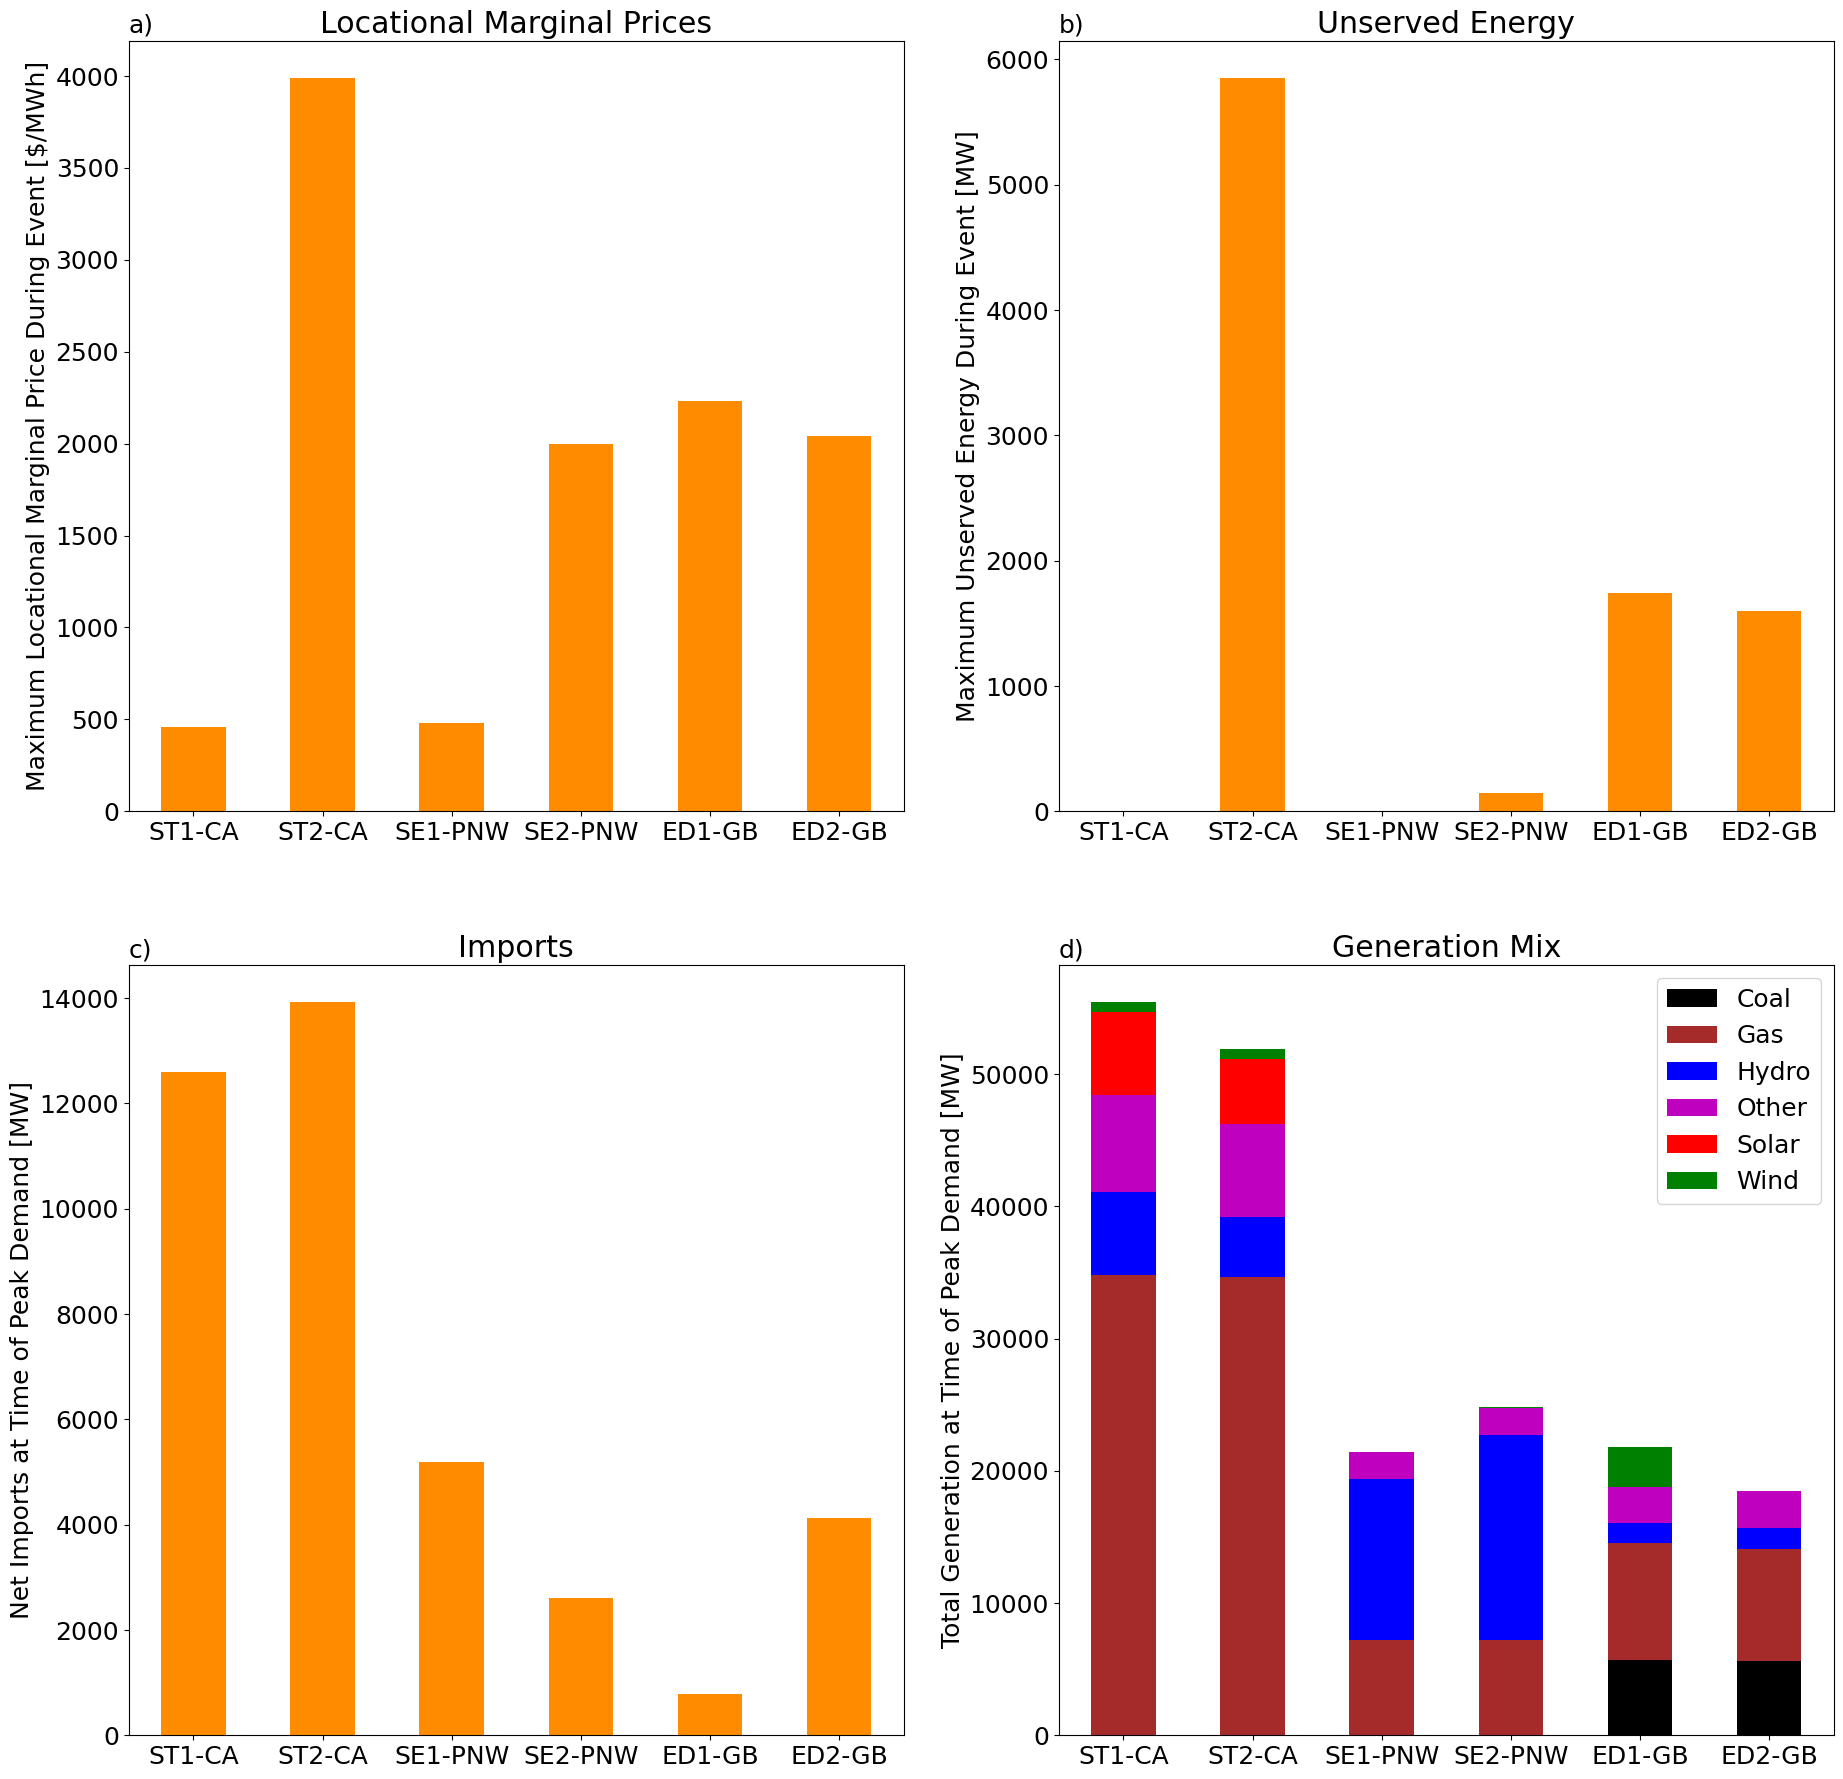

In [8]:
# Test the function:
output_df = plot_case_studies(event_list = ['HW_NERC1_Event14', 'HW_NERC1_Event67', 'HW_NERC11_Event72', 'HW_NERC11_Event53', 'HW_NERC4_Event18', 'HW_NERC4_Event17'],
                              event_label = ['ST1-CA', 'ST2-CA', 'SE1-PNW', 'SE2-PNW', 'ED1-GB', 'ED2-GB'],
                              hw_cs = 'HW',
                              events_data_input_dir = events_data_input_dir,
                              image_output_dir = image_output_dir, 
                              image_resolution = 150,
                              save_images = True)

output_df


In [ ]:
# Test the function:
output_df = plot_case_studies(event_list = ['HW_NERC1_Event37', 'HW_NERC1_Event71', 'HW_NERC11_Event19', 'HW_NERC11_Event88', 'HW_NERC4_Event14', 'HW_NERC4_Event6'],
                              event_label = ['ST1-CA', 'ST2-CA', 'SE1-PNW', 'SE2-PNW', 'ED1-GB', 'ED2-GB'],
                              hw_cs = 'HW',
                              events_data_input_dir = events_data_input_dir,
                              image_output_dir = image_output_dir, 
                              image_resolution = 150,
                              save_images = True)

output_df